# 01 — Exploratory Data Analysis: IEEE-CIS Fraud Detection

Dataset: [IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection) (Vesta e-commerce
transactions), downloaded into [`../ieee-fraud-detection/`](../ieee-fraud-detection/).

This is notebook **1 of 4** in this project's pipeline:

1. **01_eda.ipynb** (this notebook) — understand the data
2. [02_baseline_model.ipynb](02_baseline_model.ipynb) — a tabular baseline (Logistic Regression + LightGBM)
3. [03_preprocessing_gnn_features.ipynb](03_preprocessing_gnn_features.ipynb) — feature engineering + graph
   construction for a GNN
4. [04_gcn_model.ipynb](04_gcn_model.ipynb) — a GCN, compared against the notebook-2 baseline

Goals of this notebook:
- Understand target imbalance, missingness, and column groups (`card`, `addr`, `C`/`D`/`M`/`V`, identity/device)
- Look at the data through a **time** lens, since `TransactionDT` matters a lot for how we split train/valid later
- Specifically look for **shared-attribute structure** (same `card1`, `addr1`, email domain, device) that would
  justify modeling this as a graph — this motivates notebooks 3 and 4


In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fraud_utils import DATA_DIR, reduce_memory_usage

pd.options.display.max_columns = 100
plt.rcParams["figure.figsize"] = (9, 4)
%matplotlib inline


## 1. Load Data

We load the four raw CSVs separately first (before merging) so we can look at
`train_identity.csv`'s coverage relative to `train_transaction.csv` on its own.

In [2]:
train_txn = pd.read_csv(DATA_DIR / "train_transaction.csv")
train_id = pd.read_csv(DATA_DIR / "train_identity.csv")
test_txn = pd.read_csv(DATA_DIR / "test_transaction.csv")
test_id = pd.read_csv(DATA_DIR / "test_identity.csv")

for name, df in [("train_transaction", train_txn), ("train_identity", train_id),
                  ("test_transaction", test_txn), ("test_identity", test_id)]:
    print(f"{name:20s} shape={df.shape}")


train_transaction    shape=(590540, 394)
train_identity       shape=(144233, 41)
test_transaction     shape=(506691, 393)
test_identity        shape=(141907, 41)


In [3]:
train = train_txn.merge(train_id, on="TransactionID", how="left")
test = test_txn.merge(test_id, on="TransactionID", how="left")
train = reduce_memory_usage(train)
test = reduce_memory_usage(test)
print(f"train (merged): {train.shape}   test (merged): {test.shape}")
train.head()


  Memory: 2514.0 MB -> 1603.3 MB (36% reduction)
  Memory: 2164.1 MB -> 1386.1 MB (36% reduction)
train (merged): (590540, 434)   test (merged): (506691, 433)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## 2. Target Distribution

`isFraud` is only present in `train`. This is a **severely imbalanced** binary classification problem.

isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.4990%  (20,663 fraud / 590,540 total)


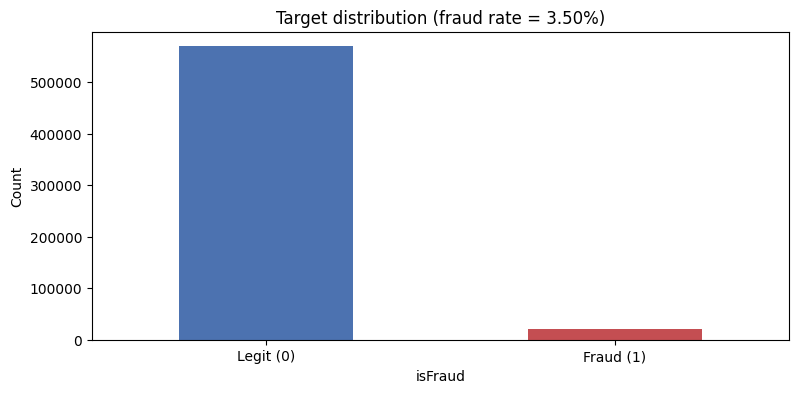

In [4]:
fraud_counts = train["isFraud"].value_counts()
fraud_rate = train["isFraud"].mean()
print(fraud_counts)
print(f"\nFraud rate: {fraud_rate:.4%}  ({fraud_counts[1]:,} fraud / {len(train):,} total)")

fig, ax = plt.subplots()
fraud_counts.sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Legit (0)", "Fraud (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title(f"Target distribution (fraud rate = {fraud_rate:.2%})")
plt.show()


## 3. Missing Values

IEEE-CIS is notoriously sparse — many `V`/`id_` columns are mostly null.

Most-missing transaction columns:
dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D9       0.873123
D8       0.873123
V153     0.861237
V139     0.861237
V162     0.861237
V161     0.861237
V154     0.861237
V138     0.861237
V158     0.861237
dtype: float64

Most-missing identity columns:
id_24    0.967088
id_25    0.964419
id_07    0.964259
id_08    0.964259
id_21    0.964231
id_26    0.964204
id_23    0.964162
id_27    0.964162
id_22    0.964162
id_18    0.687221
id_03    0.540161
id_04    0.540161
id_33    0.491871
id_09    0.480521
id_10    0.480521
dtype: float64


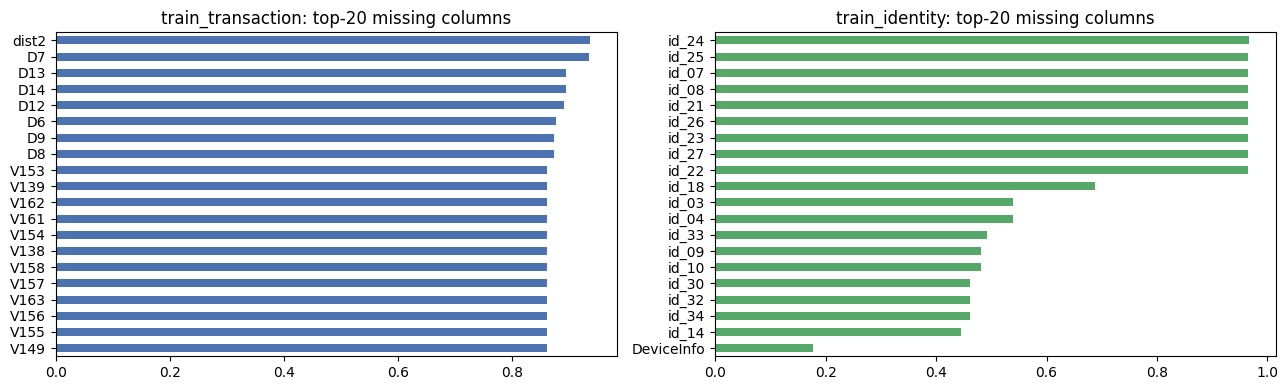

In [5]:
missing_txn = train_txn.isnull().mean().sort_values(ascending=False)
missing_id = train_id.isnull().mean().sort_values(ascending=False)

print("Most-missing transaction columns:")
print(missing_txn.head(15))
print("\nMost-missing identity columns:")
print(missing_id.head(15))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
missing_txn.head(20).plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].invert_yaxis()
axes[0].set_title("train_transaction: top-20 missing columns")
missing_id.head(20).plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].invert_yaxis()
axes[1].set_title("train_identity: top-20 missing columns")
plt.tight_layout()
plt.show()


## 4. Transaction Amount

count    590540.000000
mean        135.027161
std         239.162521
min           0.251000
25%          43.320999
50%          68.769001
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64


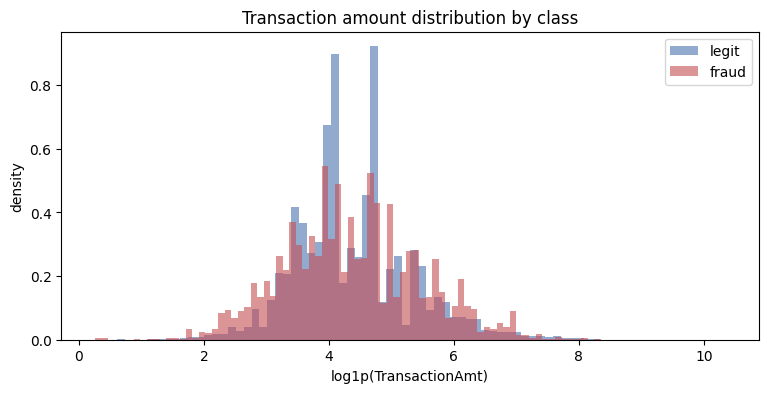

is_round_amount
0    0.034256
1    0.035677
Name: fraud_rate, dtype: float64


In [6]:
print(train["TransactionAmt"].describe())

fig, ax = plt.subplots()
ax.hist(np.log1p(train.loc[train.isFraud == 0, "TransactionAmt"]), bins=80, alpha=0.6,
        label="legit", density=True, color="#4C72B0")
ax.hist(np.log1p(train.loc[train.isFraud == 1, "TransactionAmt"]), bins=80, alpha=0.6,
        label="fraud", density=True, color="#C44E52")
ax.set_xlabel("log1p(TransactionAmt)")
ax.set_ylabel("density")
ax.set_title("Transaction amount distribution by class")
ax.legend()
plt.show()

# "Round dollar" amounts (no cents) are a classic weak fraud signal
decimal = train["TransactionAmt"] - train["TransactionAmt"].astype(int)
is_round = (decimal == 0).astype(int)
print(train.groupby(is_round)["isFraud"].mean().rename_axis("is_round_amount").rename("fraud_rate"))


## 5. Time Features (`TransactionDT`)

`TransactionDT` is seconds offset from an arbitrary reference (not a calendar timestamp), spanning ~182 days
for train. We derive hour-of-day / day-of-week and look at fraud rate over time — this also shows *why*
notebooks 2-4 use a **time-based** train/valid split rather than a random one (the real Kaggle test set is
entirely later in time than train).

/var/folders/lf/hsp4mkf14lv1k1qxwbvz70y00000gn/T/ipykernel_21927/836478343.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Transaction_day"] = (df["TransactionDT"] / (3600 * 24)).astype(int)
/var/folders/lf/hsp4mkf14lv1k1qxwbvz70y00000gn/T/ipykernel_21927/836478343.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Transaction_hour"] = ((df["TransactionDT"] / 3600) % 24).astype(int)
/var/folders/lf/hsp4mkf14lv1k1qxwbvz70y00000gn/T/ipykernel_21927/836478343.py:4: PerformanceWarning: DataFrame is highly fragmented.  T

train day range: 1-182 (181 days)
test  day range: 213-395 (182 days)
-> test is entirely AFTER train in time, hence the time-based split used later.


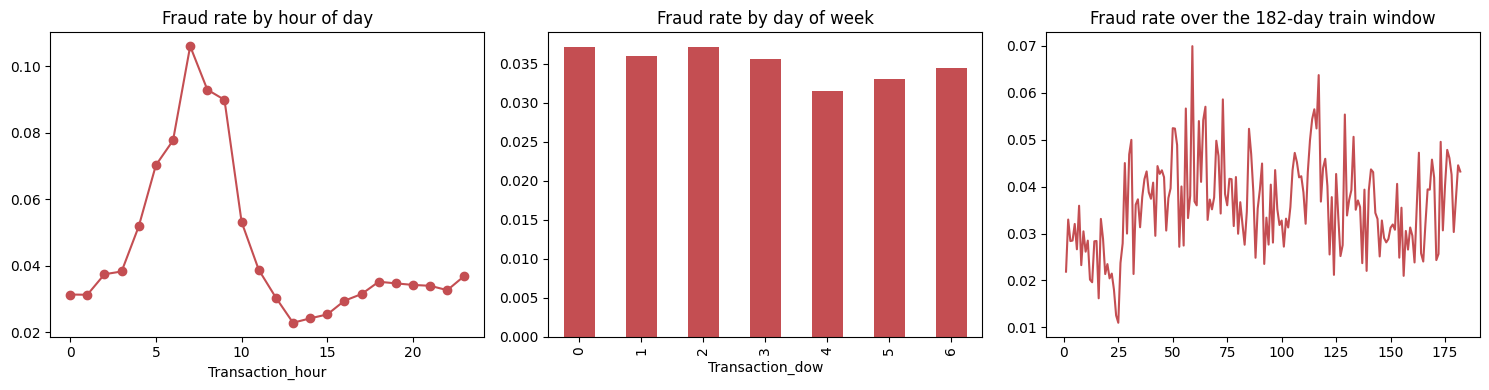

In [7]:
for df in (train, test):
    df["Transaction_day"] = (df["TransactionDT"] / (3600 * 24)).astype(int)
    df["Transaction_hour"] = ((df["TransactionDT"] / 3600) % 24).astype(int)
    df["Transaction_dow"] = df["Transaction_day"] % 7

print(f"train day range: {train.Transaction_day.min()}-{train.Transaction_day.max()} "
      f"({train.Transaction_day.max() - train.Transaction_day.min()} days)")
print(f"test  day range: {test.Transaction_day.min()}-{test.Transaction_day.max()} "
      f"({test.Transaction_day.max() - test.Transaction_day.min()} days)")
print("-> test is entirely AFTER train in time, hence the time-based split used later.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
train.groupby("Transaction_hour")["isFraud"].mean().plot(ax=axes[0], marker="o", color="#C44E52")
axes[0].set_title("Fraud rate by hour of day")
train.groupby("Transaction_dow")["isFraud"].mean().plot(ax=axes[1], kind="bar", color="#C44E52")
axes[1].set_title("Fraud rate by day of week")
daily = train.groupby("Transaction_day")["isFraud"].agg(["mean", "count"])
axes[2].plot(daily.index, daily["mean"], color="#C44E52")
axes[2].set_title("Fraud rate over the 182-day train window")
plt.tight_layout()
plt.show()


## 6. ProductCD & Card Features

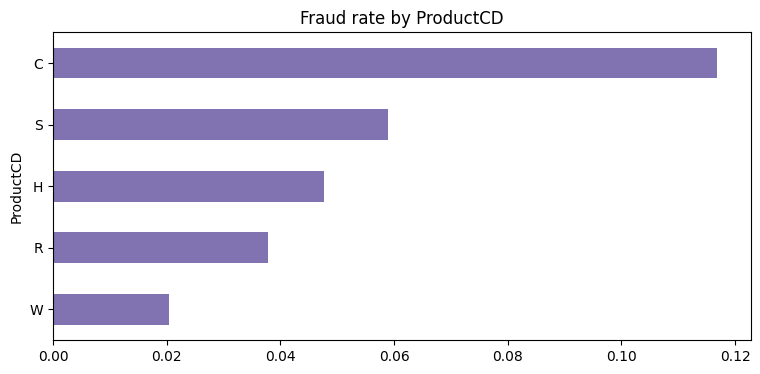

card1    unique= 13,553  null_rate=0.000
card2    unique=    500  null_rate=0.015
card3    unique=    114  null_rate=0.003
card4    unique=      4  null_rate=0.003
card5    unique=    119  null_rate=0.007
card6    unique=      4  null_rate=0.003


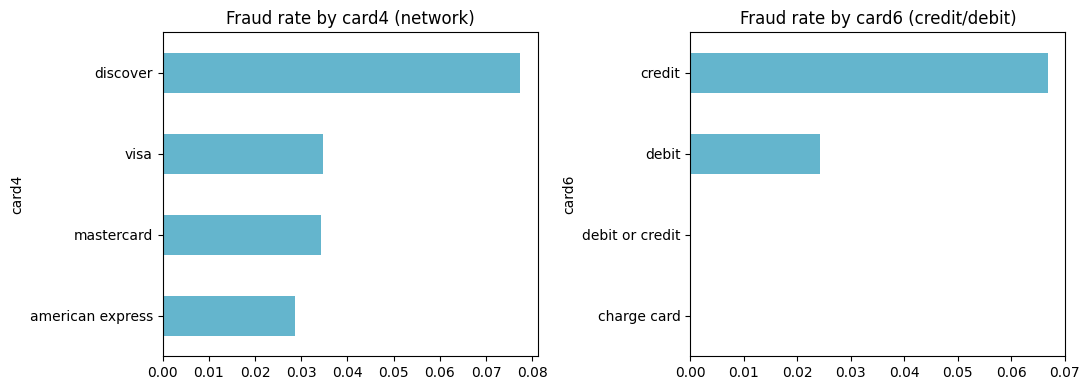

In [8]:
fig, ax = plt.subplots()
train.groupby("ProductCD")["isFraud"].mean().sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Fraud rate by ProductCD")
plt.show()

for col in ["card1", "card2", "card3", "card4", "card5", "card6"]:
    print(f"{col:8s} unique={train[col].nunique():7,d}  null_rate={train[col].isnull().mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train.groupby("card4")["isFraud"].mean().sort_values().plot(kind="barh", ax=axes[0], color="#64B5CD")
axes[0].set_title("Fraud rate by card4 (network)")
train.groupby("card6")["isFraud"].mean().sort_values().plot(kind="barh", ax=axes[1], color="#64B5CD")
axes[1].set_title("Fraud rate by card6 (credit/debit)")
plt.tight_layout()
plt.show()


## 7. Address & Distance

addr1    unique=    332  null_rate=0.111
addr2    unique=     74  null_rate=0.111
dist1    unique=  2,651  null_rate=0.597
dist2    unique=  1,751  null_rate=0.936


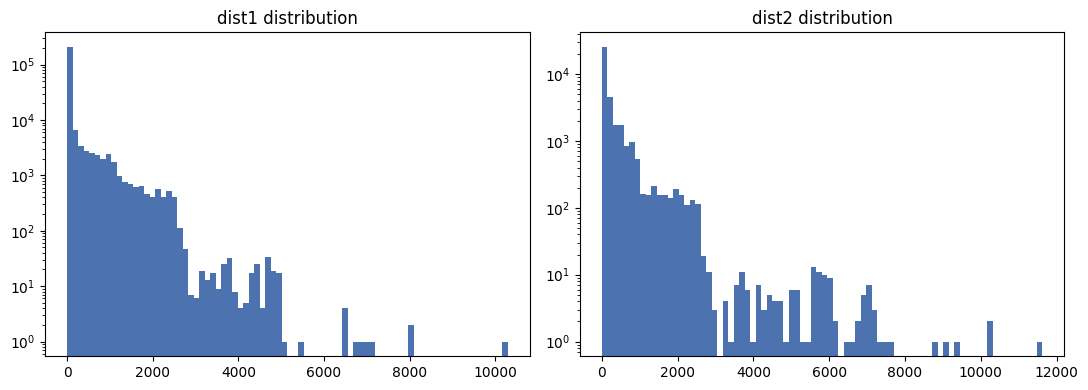

In [9]:
for col in ["addr1", "addr2", "dist1", "dist2"]:
    print(f"{col:8s} unique={train[col].nunique():7,d}  null_rate={train[col].isnull().mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train["dist1"].dropna(), bins=80, color="#4C72B0")
axes[0].set_title("dist1 distribution")
axes[0].set_yscale("log")
axes[1].hist(train["dist2"].dropna(), bins=80, color="#4C72B0")
axes[1].set_title("dist2 distribution")
axes[1].set_yscale("log")
plt.tight_layout()
plt.show()


## 8. Email Domains

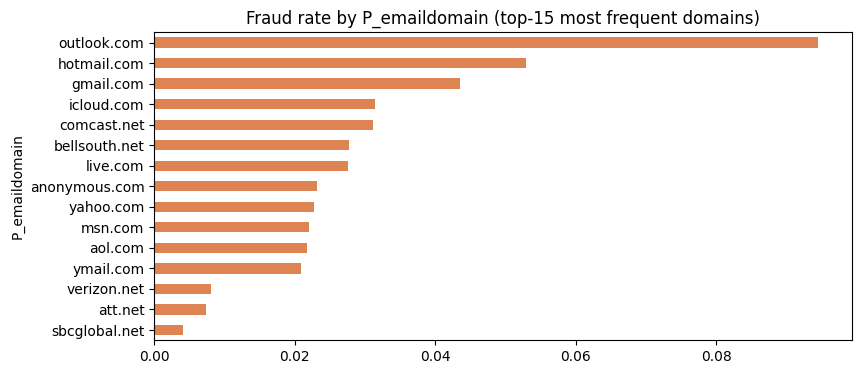

P_equals_R_emaildomain
0    0.022070
1    0.096504
Name: fraud_rate, dtype: float64


In [10]:
top_p_domains = train["P_emaildomain"].value_counts().head(15).index
domain_fraud = train[train["P_emaildomain"].isin(top_p_domains)].groupby("P_emaildomain")["isFraud"].mean()
domain_fraud.sort_values().plot(kind="barh", color="#DD8452")
plt.title("Fraud rate by P_emaildomain (top-15 most frequent domains)")
plt.show()

email_match = (train["P_emaildomain"] == train["R_emaildomain"]).astype(int)
print(train.groupby(email_match)["isFraud"].mean().rename_axis("P_equals_R_emaildomain").rename("fraud_rate"))


## 9. Identity Table Coverage & Device

Only a minority of transactions have a matching row in `train_identity.csv`. Does that coverage itself
correlate with fraud?

Transactions with identity data: 24.42%
has_identity
False    0.020939
True     0.078470
Name: fraud_rate, dtype: float64


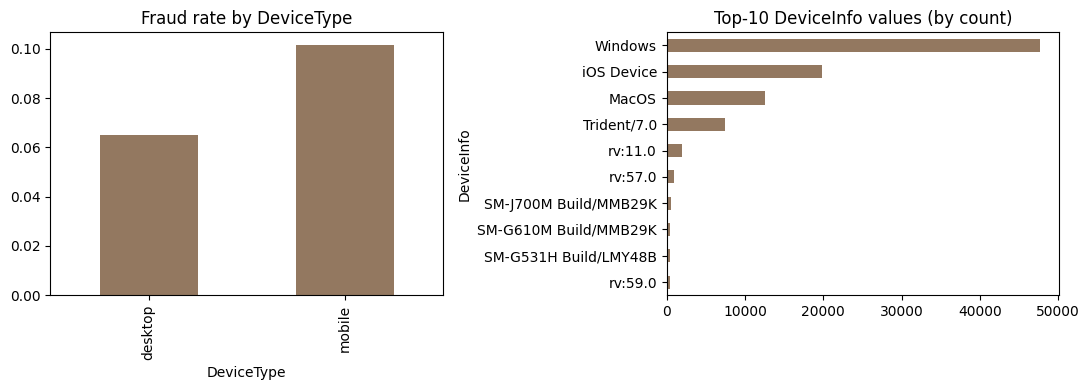

In [11]:
has_identity = train["id_01"].notnull()  # any id_ column works as a coverage proxy
print(f"Transactions with identity data: {has_identity.mean():.2%}")
print(train.groupby(has_identity)["isFraud"].mean().rename_axis("has_identity").rename("fraud_rate"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train.groupby("DeviceType")["isFraud"].mean().plot(kind="bar", ax=axes[0], color="#937860")
axes[0].set_title("Fraud rate by DeviceType")
train["DeviceInfo"].value_counts().head(10).plot(kind="barh", ax=axes[1], color="#937860")
axes[1].invert_yaxis()
axes[1].set_title("Top-10 DeviceInfo values (by count)")
plt.tight_layout()
plt.show()


## 10. C / D / M Columns

- `C1`-`C14`: counting features (e.g. # cards/addresses associated with this transaction) — mostly dense
- `D1`-`D15`: time-delta features (days since some past event) — sparse, high-signal
- `M1`-`M9`: match flags (T/F), e.g. does the billing name match the shipping name

C columns: 14   D columns: 15   M columns: 9

D-column null rates:
D7     0.934099
D13    0.895093
D14    0.894695
D12    0.890410
D6     0.876068
D8     0.873123
D9     0.873123
D5     0.524674
D2     0.475492
D11    0.472935
D3     0.445149
D4     0.286047
D15    0.150901
D10    0.128733
D1     0.002149
dtype: float64


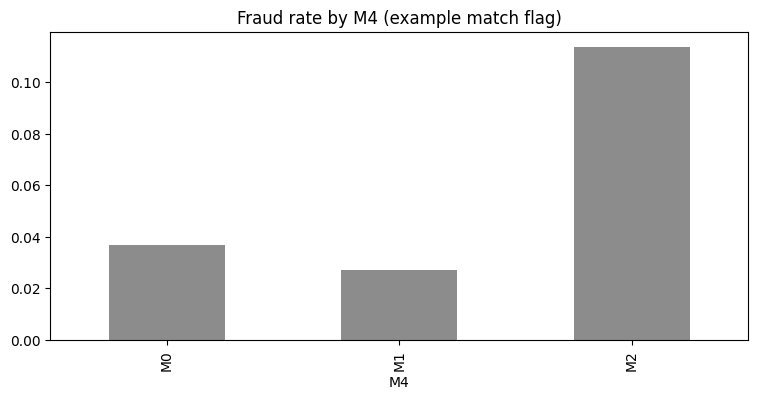

In [12]:
c_cols = [c for c in train.columns if c.startswith("C") and c[1:].isdigit()]
d_cols = [c for c in train.columns if c.startswith("D") and c[1:].isdigit()]
m_cols = [c for c in train.columns if c.startswith("M") and c[1:].isdigit()]
print(f"C columns: {len(c_cols)}   D columns: {len(d_cols)}   M columns: {len(m_cols)}")

print("\nD-column null rates:")
print(train[d_cols].isnull().mean().sort_values(ascending=False))

fig, ax = plt.subplots()
train.groupby("M4")["isFraud"].mean().plot(kind="bar", ax=ax, color="#8C8C8C")
ax.set_title("Fraud rate by M4 (example match flag)")
plt.show()


## 11. V-Columns (anonymized Vesta features)

339 opaque engineered features (`V1`-`V339`). We rank by variance among low-missingness columns —
this is the same selection notebook 3 uses to keep a manageable top-50 subset for the GNN.

339 V-columns total; 180 have <50% missing

Top-20 V-columns by variance:
V307    1.928960e+07
V127    1.796630e+07
V317    1.584074e+07
V133    1.441202e+07
V308    9.132026e+06
V128    9.061658e+06
V318    7.802768e+06
V134    7.689456e+06
V306    5.517094e+06
V126    5.508182e+06
V316    5.153050e+06
V132    5.135237e+06
V320    2.242016e+05
V136    2.041308e+05
V321    1.459646e+05
V310    1.245971e+05
V137    1.213357e+05
V319    1.104265e+05
V130    9.983103e+04
V135    8.634639e+04
dtype: float32


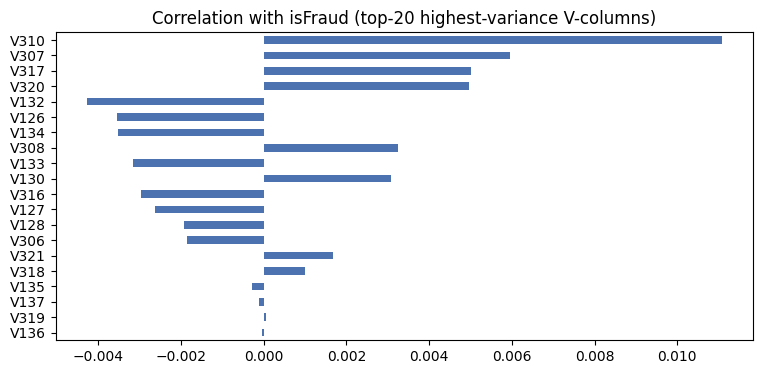

In [13]:
v_cols = [c for c in train.columns if c.startswith("V") and c[1:].isdigit()]
v_null_rate = train[v_cols].isnull().mean()
print(f"{len(v_cols)} V-columns total; {sum(v_null_rate < 0.5)} have <50% missing")

v_keep_candidates = v_null_rate[v_null_rate < 0.5].index
v_variance = train[v_keep_candidates].var().sort_values(ascending=False)
top20_v = v_variance.head(20)
print("\nTop-20 V-columns by variance:")
print(top20_v)

corrs = train[top20_v.index.tolist() + ["isFraud"]].corr()["isFraud"].drop("isFraud").sort_values(key=abs, ascending=False)
corrs.plot(kind="barh", color="#4C72B0")
plt.title("Correlation with isFraud (top-20 highest-variance V-columns)")
plt.gca().invert_yaxis()
plt.show()


## 12. Correlation With Target (broader view)

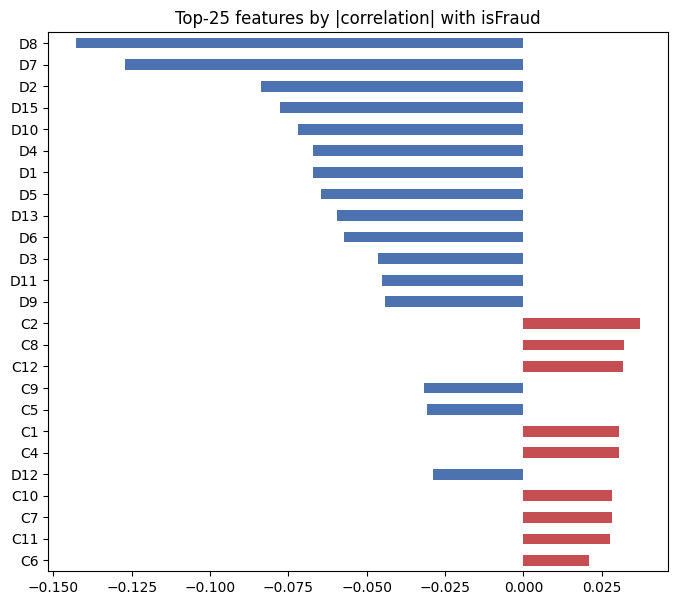

In [14]:
numeric_candidates = ["TransactionAmt"] + c_cols + d_cols + top20_v.index.tolist()
corr_all = train[numeric_candidates + ["isFraud"]].corr()["isFraud"].drop("isFraud")
corr_all = corr_all.reindex(corr_all.abs().sort_values(ascending=False).index).head(25)

fig, ax = plt.subplots(figsize=(8, 7))
corr_all.plot(kind="barh", ax=ax, color=corr_all.apply(lambda v: "#C44E52" if v > 0 else "#4C72B0"))
ax.invert_yaxis()
ax.set_title("Top-25 features by |correlation| with isFraud")
plt.show()


## 13. Graph Structure Potential (for the GNN notebooks)

The premise of the GNN approach in this repo (see [../README.md](../README.md)) is that fraudsters **reuse**
infrastructure — the same `card1`, `addr1`, email domain, or device across multiple transactions. If that's
true, transactions in larger shared-attribute groups should show a different (usually higher) fraud rate.

In [15]:
def group_size_vs_fraud(df, col, max_bucket=20):
    sizes = df.groupby(col)[col].transform("count")
    bucket = pd.cut(sizes, bins=[0, 1, 2, 5, 10, 20, 50, sizes.max()],
                     labels=["1", "2", "3-5", "6-10", "11-20", "21-50", "50+"])
    return df.groupby(bucket, observed=True)["isFraud"].agg(["mean", "count"])

for col in ["card1", "addr1", "P_emaildomain", "DeviceInfo"]:
    print(f"\n--- shared-{col} group size vs. fraud rate ---")
    print(group_size_vs_fraud(train, col))



--- shared-card1 group size vs. fraud rate ---
           mean   count
card1                  
1      0.042393    3444
2      0.031065    3380
3-5    0.028649    9634
6-10   0.026424   14154
11-20  0.024940   22133
21-50  0.025602   41637
50+    0.036569  496158

--- shared-addr1 group size vs. fraud rate ---
           mean   count
addr1                  
1      0.000000     123
2      0.026316      76
3-5    0.018750     160
6-10   0.039409     203
11-20  0.040359     223
21-50  0.161137     422
50+    0.024506  523627

--- shared-P_emaildomain group size vs. fraud rate ---
                  mean   count
P_emaildomain                 
21-50          0.00000     159
50+            0.03604  495925

--- shared-DeviceInfo group size vs. fraud rate ---
                mean   count
DeviceInfo                  
1           0.027273     440
2           0.053299     394
3-5         0.076051    1499
6-10        0.101436    2159
11-20       0.143830    2642
21-50       0.139802    5050
50+    

## Summary of EDA Findings

- **Severe class imbalance**: fraud rate ≈ 3.5%. Every downstream model needs class weighting / imbalance-aware
  metrics (AUC, PR-AUC — not accuracy).
- **Heavy missingness**: many `V`, `id_`, and `D` columns are mostly null; `train_identity` only covers a
  minority of transactions. Any preprocessing needs deliberate imputation and V-column selection.
- **`TransactionDT` matters**: the real Kaggle test set is entirely *after* train in time, so notebooks
  2-4 use a **time-based** train/valid split (`fraud_utils.time_based_split`), not a random one.
- **Several categorical/behavioral fields correlate with fraud**: `ProductCD`, `card4`/`card6`, specific email
  domains, `DeviceType`, and various `C`/`D`/high-variance `V` columns.
- **Shared-attribute groups do carry fraud signal** (Section 13) — transactions that share a card, address,
  email domain, or device with many other transactions have a measurably different fraud rate than singletons.
  This is the empirical justification for modeling transactions as a **graph** with edges on shared attributes,
  which is exactly what notebooks 3 and 4 do.

**Next**: [02_baseline_model.ipynb](02_baseline_model.ipynb) builds a tabular baseline (Logistic Regression +
LightGBM) to set the number the GCN in notebook 4 needs to beat.
